# Data Preparation

In [1]:
import os
import pandas as pd
import numpy as np

data_dir = "../data"
file_paths = {
    "presentations_df": os.path.join(data_dir, "presentations_df.csv"),
    "user_profiles": os.path.join(data_dir, "user_profiles.csv"),
    "user_profiles_flat": os.path.join(data_dir, "user_profiles_flat.csv"),
    "recommendations": os.path.join(data_dir, "recommendations.csv"),
    "ratings_matrix": os.path.join(data_dir, "ratings_matrix.csv"),
    "interaction_data": os.path.join(data_dir, "interaction_data.csv"),
    "X": os.path.join(data_dir, "X.csv"),
    "y": os.path.join(data_dir, "y.csv"),
    "feature_columns": os.path.join(data_dir, "feature_columns.txt")
}

def safe_read_csv(path, name):
    if os.path.exists(path):
        return pd.read_csv(path)
    else:
        print(f"⚠️ File not found: {name} -> {path}")
        return None

# Load all CSVs
presentations_df = safe_read_csv(file_paths["presentations_df"], "presentations_df")
user_profiles = safe_read_csv(file_paths["user_profiles"], "user_profiles")
user_profiles_flat = safe_read_csv(file_paths["user_profiles_flat"], "user_profiles_flat")
recommendations = safe_read_csv(file_paths["recommendations"], "recommendations")
ratings_matrix = safe_read_csv(file_paths["ratings_matrix"], "ratings_matrix")
interaction_data = safe_read_csv(file_paths["interaction_data"], "interaction_data")

# Load X and y
X_df = safe_read_csv(file_paths["X"], "X")
X = X_df.values if X_df is not None else None

y_df = safe_read_csv(file_paths["y"], "y")
y = y_df.values.flatten() if y_df is not None else None

# Load feature columns
if os.path.exists(file_paths["feature_columns"]):
    with open(file_paths["feature_columns"], "r") as f:
        feature_columns = [line.strip() for line in f]
else:
    print(f"⚠️ File not found: feature_columns.txt -> {file_paths['feature_columns']}")
    feature_columns = None


In [2]:
#!pip install nbimporter


In [3]:
import nbimporter
from dataset_generator import prepare_recommendation_system_input_data  # use any function or class from that notebook
from utils_notebook import evaluate_regression_model 
from utility_score_module import add_utility_scr_recommendations

In [6]:
# print(interaction_data.columns)


# Data Preparation

In [33]:

# import pandas as pd

# # Convert timestamp to datetime format
# interaction_data["timestamp"] = pd.to_datetime(interaction_data["timestamp"])

# # Compute time_since in hours from the most recent timestamp
# max_timestamp = interaction_data["timestamp"].max()
# interaction_data["time_since"] = (max_timestamp - interaction_data["timestamp"]).dt.total_seconds() / 3600
# ######### time_since become days_since_last_rating

In [4]:
user_features_names=['user_preference_Boring presentation',
 'user_preference_Graphics',
 'user_preference_Readability',
 'user_preference_Consistency',
 'user_preference_Images',
 'user_preference_Bullets',
 'user_preference_Text size',
 'user_preference_Text heavy',
 'user_preference_Tables',
 'user_preference_Agenda',
 'user_preference_Infographics',
 'user_preference_Positioning',
 'user_preference_Presentation length',
 'user_preference_General tips',
 'user_preference_Presentation skills',
 'user_preference_Powerpoint knowledge',
 'user_preference_tips and tricks',
 'user_preference_Explanation of the problem',
 'user_type_business',
 'user_type_teacher',
 'user_type_student',
 'user_type_researcher',
 'user_type_manager',
 'user_type_technical',
 'user_type_specialist',
 'presentation_type_formal_x',
 'presentation_type_creative_x',
 'presentation_type_students_x',
 'presentation_type_technical_x',
 'presentation_type_branding_x']
item_features_names=[ 'Boring presentation',
 'Graphics',
 'Readability',
 'Consistency',
 'Images',
 'Bullets',
 'Text size',
 'Text heavy',
 'Tables',
 'Agenda',
 'Infographics',
 'Positioning',
 'Presentation length',
 'General tips',
 'Presentation skills',
 'Powerpoint knowledge',
 'tips and tricks',
 'Explanation of the problem',
 'presentation_type_formal_y',
 'presentation_type_creative_y',
 'presentation_type_students_y',
 'presentation_type_technical_y',
 'presentation_type_branding_y',
 'audience_type_academic',
 'audience_type_business',
 'audience_type_kids',
 'audience_type_general',
 'audience_type_creative',
 'audience_type_specialized']


In [5]:
import numpy as np
import pandas as pd


interaction_data = interaction_data.sort_values(by=['user_id', 'article_id']).reset_index(drop=True)

def extract_time_features(dates, start_time):
    # Convert to datetime with UTC if not already
    df_temp = pd.DataFrame({'Datetime': pd.to_datetime(dates, errors='coerce')})

    # Ensure timezone awareness (UTC)
    if df_temp['Datetime'].dt.tz is None:
        df_temp['Datetime'] = df_temp['Datetime'].dt.tz_localize('UTC')
    else:
        df_temp['Datetime'] = df_temp['Datetime'].dt.tz_convert('UTC')

    # Ensure start_time is timezone-aware
    start_time = pd.to_datetime(start_time, utc=True)

    # Sort values
    df_temp = df_temp.sort_values(by='Datetime').reset_index(drop=True)

    # Extract cyclical time features
    df_temp['Hour'] = df_temp['Datetime'].dt.hour
    df_temp['Day_of_Week'] = df_temp['Datetime'].dt.dayofweek
    df_temp['Hour_sin'] = np.sin(2 * np.pi * df_temp['Hour'] / 24)
    df_temp['Hour_cos'] = np.cos(2 * np.pi * df_temp['Hour'] / 24)
    df_temp['Day_sin'] = np.sin(2 * np.pi * df_temp['Day_of_Week'] / 7)
    df_temp['Day_cos'] = np.cos(2 * np.pi * df_temp['Day_of_Week'] / 7)

    # Time since first submission in hours
    df_temp['Time_since_first_submission_hours'] = (
        (df_temp['Datetime'] - start_time).dt.total_seconds() / 3600
    ).astype(np.float32)

    return df_temp[['Hour_sin', 'Hour_cos', 'Day_sin', 'Day_cos', 'Time_since_first_submission_hours']]

# Ensure start_time is timezone-aware
start_time = pd.to_datetime("2005-12-01 00:00:00", utc=True)

# Apply time feature extraction to interaction and presentation data
time_features = extract_time_features(interaction_data['timestamp'], start_time)

user_features = interaction_data[user_features_names]
item_features = interaction_data[item_features_names]
X_user_id = interaction_data['user_id']
X_item_id = interaction_data['article_id']

# Problem features
problem_features = [
    'Boring presentation', 'Graphics', 'Readability', 'Consistency',
    'Images', 'Bullets', 'Text size', 'Text heavy', 'Tables',
    'Agenda', 'Infographics', 'Positioning'
]

# Process presentation features and timestamps
presentation_df_temp = presentations_df.sort_values(by='user_id').reset_index(drop=True)
presentation_submission_date_df = extract_time_features(presentation_df_temp['submission_date'], start_time)

# Concatenate user_id, problem features, and time features
problem_sequences_df = pd.concat(
    [presentations_df['user_id'], presentations_df[problem_features], presentation_submission_date_df],
    axis=1
)

y = interaction_data['rating']


In [6]:
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import numpy as np
import pandas as pd
from datetime import datetime, timedelta

def calculate_problem_weights(df, date_column, problem_columns, days_window=90, decay_factor=0.01, apply_filter=True):
    """
    Изчислява претеглена вероятност за всеки проблем на база на презентации от последните days_window дни.
    
    Важно: Колоната, зададена с date_column, съдържа време в часове от първата подадена презентация.
    
    :param df: DataFrame с колоните [date_column] и [problem_columns]
    :param date_column: Име на колоната, която съдържа времето (в часове) от първата submission.
    :param problem_columns: Списък с колоните за проблемите (0 или 1)
    :param days_window: Колко дни назад да се вземат презентации (по подразбиране 90 дни)
    :param decay_factor: Фактор на затихване (по подразбиране 0.01)
    :param apply_filter: Ако True, филтрира по времевия прозорец. Ако False, използва целия DataFrame.
    :return: df_filtered (или оригиналния df ако не се филтрира) и NumPy масив с претеглените стойности за всеки проблем.
    """
    
    # Ако DataFrame има само един ред, връщаме директно неговите стойности.
    if len(df) <= 1:
        arr = np.array([df[col].iloc[0] if not df.empty else 0 for col in problem_columns])
        return df, arr

    # Ако apply_filter е True, филтрираме редовете според времевия прозорец.
    # Изчисляваме прага в часове (дни_window * 24)
    if apply_filter:
        threshold_hours = days_window * 24
        df_filtered = df[df[date_column] <= threshold_hours]
    else:
        df_filtered = df.copy()

    # Ако след филтрирането няма редове, връщаме масив със 0 стойности.
    if df_filtered.empty:
        print("No data after filtering. Returning zeros.")
        return df, np.array([0 for _ in problem_columns])
    
    # Изчисляване на тежестите спрямо възрастта на презентациите.
    # Тъй като колоната е в часове, преобразуваме часовете в дни (делим на 24)
    # за да запазим decay_factor, дефиниран за дни.
    df_filtered["weight"] = np.exp(-decay_factor * (df_filtered[date_column] / 24))
    
    # Изчисляване на претегленото средно за всеки проблем
    weighted_problems = np.array([
        (df_filtered[col] * df_filtered["weight"]).sum() / df_filtered["weight"].sum() 
        for col in problem_columns
    ])
    
    return df_filtered, weighted_problems

padded_problem_sequences = []
user_data = {}

for user_id_to_fetch in X_user_id:
    if user_id_to_fetch in user_data:
        # If user data is already calculated, use it directly
        weighted_problems = user_data[user_id_to_fetch]
    else:
        # Filter the DataFrame for the current user
        df_user = problem_sequences_df[problem_sequences_df['user_id'] == user_id_to_fetch]
        # Calculate weighted problems
        _, weighted_problems = calculate_problem_weights(df_user, 
                                                          "Time_since_first_submission_hours", 
                                                          problem_features, 
                                                          days_window=180, 
                                                          decay_factor=0.01, 
                                                          apply_filter=False)
        
        # Store the result in user_data
        user_data[user_id_to_fetch] = weighted_problems
    
    # Append to padded_problem_sequences
    padded_problem_sequences.append(weighted_problems)
    
padded_problem_sequences = np.array(padded_problem_sequences)

# If it's 1D  reshape to 2D Keras typically expects a 2D tensor for each input, where:The first dimension (axis 0) represents the number of samples in the batch.The second dimension (axis 1) represents the features for each sample.
if len(padded_problem_sequences.shape) == 1:
    padded_problem_sequences = padded_problem_sequences.reshape(-1, 1)

padded_problem_sequences


array([[0., 1., 1., ..., 0., 1., 0.],
       [0., 1., 1., ..., 0., 1., 0.],
       [0., 1., 1., ..., 0., 1., 0.],
       ...,
       [0., 1., 1., ..., 0., 0., 0.],
       [0., 1., 1., ..., 0., 0., 0.],
       [0., 1., 1., ..., 0., 0., 0.]])

In [7]:
# Verify lengths
print("X_user_id:", len(X_user_id))
print("X_item_id:", len(X_item_id))
print("time_features:", len(time_features))
print("padded_problem_sequences:", len(padded_problem_sequences))
print("user_features:", len(user_features))
print("item_features:", len(item_features))
print("y:", len(y))  # Ensure y also has 25,000 elements

X_user_id: 3000
X_item_id: 3000
time_features: 3000
padded_problem_sequences: 3000
user_features: 3000
item_features: 3000
y: 3000


In [10]:
print("X_user_id:", np.array(X_user_id).shape)
print("X_item_id:", np.array(X_item_id).shape)
print("time_features:", np.array(time_features).shape)
print("padded_problem_sequences:", np.array(padded_problem_sequences).shape)
print("user_features:", np.array(user_features).shape)
print("item_features:", np.array(item_features).shape)
print("y (labels):", np.array(y).shape)


X_user_id: (3000,)
X_item_id: (3000,)
time_features: (3000, 5)
padded_problem_sequences: (3000, 12)
user_features: (3000, 30)
item_features: (3000, 29)
y (labels): (3000,)


In [8]:
from sklearn.model_selection import train_test_split
import numpy as np

# Ensure all feature lists have consistent length
assert len(X_user_id) == len(X_item_id) == len(time_features) == len(padded_problem_sequences) == len(user_features) == len(item_features) == len(y), "Feature lengths do not match!"

# Split data into train (70%) and temp (30%)
X_user_id_train, X_user_id_temp, \
X_item_id_train, X_item_id_temp, \
time_features_train, time_features_temp, \
padded_problem_sequences_train, padded_problem_sequences_temp, \
user_features_train, user_features_temp, \
item_features_train, item_features_temp, \
y_train, y_temp = train_test_split(
    X_user_id, X_item_id, time_features, padded_problem_sequences, user_features, item_features, y, 
    test_size=0.3, random_state=42
)

# Split temp into validation (15%) and test (15%)
X_user_id_val, X_user_id_test, \
X_item_id_val, X_item_id_test, \
time_features_val, time_features_test, \
padded_problem_sequences_val, padded_problem_sequences_test, \
user_features_val, user_features_test, \
item_features_val, item_features_test, \
y_val, y_test = train_test_split(
    X_user_id_temp, X_item_id_temp, time_features_temp, padded_problem_sequences_temp, 
    user_features_temp, item_features_temp, y_temp, 
    test_size=0.5, random_state=42
)

# Convert lists to NumPy arrays for easier processing
train_user_features = np.array(user_features_train)
train_item_features = np.array(item_features_train)
train_time_features = np.array(time_features_train)
train_problem_seq = np.array(padded_problem_sequences_train)
train_labels = np.array(y_train)

val_user_features = np.array(user_features_val)
val_item_features = np.array(item_features_val)
val_time_features = np.array(time_features_val)
val_problem_seq = np.array(padded_problem_sequences_val)
val_labels = np.array(y_val)

test_user_features = np.array(user_features_test)
test_item_features = np.array(item_features_test)
test_time_features = np.array(time_features_test)
test_problem_seq = np.array(padded_problem_sequences_test)
test_labels = np.array(y_test)

# Print dataset sizes to confirm
print(f"Train size: {len(train_labels)}")
print(f"Validation size: {len(val_labels)}")
print(f"Test size: {len(test_labels)}")
print("✅ Data successfully split into train, validation, and test sets!")


Train size: 2100
Validation size: 450
Test size: 450
✅ Data successfully split into train, validation, and test sets!


Keras tuner section used for extracting the best hyperparameters of the model

In [ ]:
# import numpy as np
# import tensorflow as tf
# from tensorflow.keras.models import Model
# from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization, Concatenate
# from tensorflow.keras.optimizers import Adam
# from tensorflow.keras.regularizers import l2
# import kerastuner as kt

# def model_builder(hp):
#     """
#     Builds a model with hyperparameters chosen by Keras Tuner.
    
#     Assumes that the following global variables exist and define the input shapes:
#       - user_features, item_features, time_features, padded_problem_sequences
      
#     These should be NumPy arrays (or at least their shapes are known).
#     """
#     # Define input layers (using global shape information)
#     user_feat_in = Input(shape=(user_features.shape[1],), name="user_feat_input")
#     item_feat_in = Input(shape=(item_features.shape[1],), name="item_feat_input")
#     time_in = Input(shape=(time_features.shape[1],), name="time_input")
#     problem_seq_in = Input(shape=(padded_problem_sequences.shape[1],), name="problem_seq_input")
    
#     # Regularization strength fixed (you could also tune this if desired)
#     regularizer = l2(1e-4)
    
#     # ----- User Tower -----
#     user_units = hp.Choice('user_units', values=[64, 128, 256], default=128)
#     user_dropout = hp.Float('user_dropout', min_value=0.2, max_value=0.5, step=0.1, default=0.3)
#     x_user = Dense(user_units, activation="relu", kernel_regularizer=regularizer)(user_feat_in)
#     x_user = BatchNormalization()(x_user)
#     x_user = Dropout(user_dropout)(x_user)
#     user_emb_units = hp.Choice('user_emb_units', values=[16, 32, 64], default=32)
#     user_emb = Dense(user_emb_units, activation="relu", kernel_regularizer=regularizer, name="user_embedding")(x_user)
    
#     # ----- Item Tower -----
#     item_units = hp.Choice('item_units', values=[64, 128, 256], default=128)
#     item_dropout = hp.Float('item_dropout', min_value=0.2, max_value=0.5, step=0.1, default=0.3)
#     x_item = Dense(item_units, activation="relu", kernel_regularizer=regularizer)(item_feat_in)
#     x_item = BatchNormalization()(x_item)
#     x_item = Dropout(item_dropout)(x_item)
#     item_emb_units = hp.Choice('item_emb_units', values=[16, 32, 64], default=32)
#     item_emb = Dense(item_emb_units, activation="relu", kernel_regularizer=regularizer, name="item_embedding")(x_item)
    
#     # ----- Temporal Features Tower -----
#     time_units = hp.Choice('time_units', values=[8, 16, 32], default=16)
#     time_dropout = hp.Float('time_dropout', min_value=0.1, max_value=0.3, step=0.1, default=0.2)
#     x_time = Dense(time_units, activation="relu", kernel_regularizer=regularizer)(time_in)
#     x_time = BatchNormalization()(x_time)
#     x_time = Dropout(time_dropout)(x_time)
    
#     # ----- Problem Sequence Tower -----
#     problem_units = hp.Choice('problem_units', values=[32, 64, 128], default=64)
#     problem_dropout = hp.Float('problem_dropout', min_value=0.2, max_value=0.5, step=0.1, default=0.3)
#     x_problem = Dense(problem_units, activation="relu", kernel_regularizer=regularizer)(problem_seq_in)
#     x_problem = BatchNormalization()(x_problem)
#     x_problem = Dropout(problem_dropout)(x_problem)
#     problem_emb_units = hp.Choice('problem_emb_units', values=[16, 32, 64], default=32)
#     problem_emb = Dense(problem_emb_units, activation="relu", kernel_regularizer=regularizer)(x_problem)
    
#     # ----- Merge Towers -----
#     merged = Concatenate()([user_emb, item_emb, x_time, problem_emb])
#     merged_units = hp.Choice('merged_units', values=[32, 64, 128], default=64)
#     x = Dense(merged_units, activation="relu", kernel_regularizer=regularizer)(merged)
#     x = BatchNormalization()(x)
#     merged_dropout = hp.Float('merged_dropout', min_value=0.2, max_value=0.5, step=0.1, default=0.4)
#     x = Dropout(merged_dropout)(x)
#     second_merged_units = hp.Choice('merged_units2', values=[16, 32, 64], default=32)
#     x = Dense(second_merged_units, activation="relu", kernel_regularizer=regularizer)(x)
    
#     # Final output layer (regression)
#     output = Dense(1, activation="linear")(x)
    
#     model = Model(inputs=[user_feat_in, item_feat_in, time_in, problem_seq_in], outputs=output)
    
#     # Tune the learning rate as well
#     learning_rate = hp.Float('learning_rate', min_value=1e-5, max_value=1e-3, sampling='LOG', default=5e-4)
#     model.compile(optimizer=Adam(learning_rate=learning_rate), loss="mse", metrics=["mae"])
    
#     return model

# # Define a Hyperband tuner (you can also use RandomSearch or BayesianOptimization)
# tuner = kt.Hyperband(
#     model_builder,
#     objective='val_loss',
#     max_epochs=50,
#     factor=3,
#     directory='my_tuner',
#     project_name='multy_tower_search'
# )

# # Callback to stop early if no improvement
# stop_early = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10)

# # Assume you have your training and validation data prepared as NumPy arrays:
# # For example:
# #   train_user_features, train_item_features, train_time_features, train_problem_seq, train_labels
# #   val_user_features, val_item_features, val_time_features, val_problem_seq, val_labels

# # Start the hyperparameter search
# tuner.search(
#     [train_user_features, train_item_features, train_time_features, train_problem_seq],
#     train_labels,
#     epochs=50,
#     validation_data=(
#         [val_user_features, val_item_features, val_time_features, val_problem_seq],
#         val_labels
#     ),
#     callbacks=[stop_early]
# )

# # Retrieve the best model.
# best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
# print("Best hyperparameters:")
# print(best_hps.values)

#BUild a model without a tuner to fit the article

In [9]:
# best_hps ={
#     'user_units': 128,                     # User Tower: Dense 128
#     'user_dropout': 0.3,
#     'user_emb_units': 16,

#     'item_units': 256,                     # Item Tower: Dense 256 (updated to match article)
#     'item_dropout': 0.3,
#     'item_emb_units': 16,

#     'time_units': 16,                      # Time Tower: Dense 16 (updated)
#     'time_dropout': 0.1,

#     'problem_units': 32,                   # Problem Tower: Dense 32 (already matches)
#     'problem_dropout': 0.5,
#     'problem_emb_units': 32,

#     'merged_units': 128,                   # After Concatenation: Dense 128 (updated)
#     'merged_dropout': 0.2,
#     'merged_units2': 32,                   # Second merged layer: Dense 32 (already matches)

#     'learning_rate': 0.001,

#     'tuner/epochs': 50,
#     'tuner/initial_epoch': 17,
#     'tuner/bracket': 2,
#     'tuner/round': 2,
#     'tuner/trial_id': 'b5209c8832ddbbac389bfba769f0deeb'
# }

# import numpy as np
# import tensorflow as tf
# import kerastuner as kt
# from tensorflow.keras.models import Model
# from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization, Concatenate
# from tensorflow.keras.optimizers import Adam
# from tensorflow.keras.regularizers import l2

# def build_model_from_best_hps(best_hps, input_shapes):
#     reg = l2(1e-4)

#     # Input shapes
#     user_input = Input(shape=(input_shapes['user'],), name="user_feat_input")
#     item_input = Input(shape=(input_shapes['item'],), name="item_feat_input")
#     time_input = Input(shape=(input_shapes['time'],), name="time_input")
#     problem_input = Input(shape=(input_shapes['problem'],), name="problem_seq_input")

#     # User tower
#     x_user = Dense(best_hps['user_units'], activation="relu", kernel_regularizer=reg)(user_input)
#     x_user = BatchNormalization()(x_user)
#     x_user = Dropout(best_hps['user_dropout'])(x_user)
#     user_emb = Dense(best_hps['user_emb_units'], activation="relu", kernel_regularizer=reg)(x_user)

#     # Item tower
#     x_item = Dense(best_hps['item_units'], activation="relu", kernel_regularizer=reg)(item_input)
#     x_item = BatchNormalization()(x_item)
#     x_item = Dropout(best_hps['item_dropout'])(x_item)
#     item_emb = Dense(best_hps['item_emb_units'], activation="relu", kernel_regularizer=reg)(x_item)

#     # Time tower
#     x_time = Dense(best_hps['time_units'], activation="relu", kernel_regularizer=reg)(time_input)
#     x_time = BatchNormalization()(x_time)
#     x_time = Dropout(best_hps['time_dropout'])(x_time)

#     # Problem tower
#     x_problem = Dense(best_hps['problem_units'], activation="relu", kernel_regularizer=reg)(problem_input)
#     x_problem = BatchNormalization()(x_problem)
#     x_problem = Dropout(best_hps['problem_dropout'])(x_problem)
#     problem_emb = Dense(best_hps['problem_emb_units'], activation="relu", kernel_regularizer=reg)(x_problem)

#     # Merge
#     merged = Concatenate()([user_emb, item_emb, x_time, problem_emb])
#     x = Dense(best_hps['merged_units'], activation="relu", kernel_regularizer=reg)(merged)
#     x = BatchNormalization()(x)
#     x = Dropout(best_hps['merged_dropout'])(x)
#     x = Dense(best_hps['merged_units2'], activation="relu", kernel_regularizer=reg)(x)
    
#     # Output
#     output = Dense(1, activation="linear")(x)

#     model = Model(inputs=[user_input, item_input, time_input, problem_input], outputs=output)
#     model.compile(optimizer=Adam(learning_rate=best_hps['learning_rate']), loss="mse", metrics=["mae"])
    
#     return model

# from sklearn.model_selection import KFold
# import numpy as np
# import time


# # Step 1: Combine train and validation sets
# X_user_all = np.concatenate([train_user_features, val_user_features], axis=0)
# X_item_all = np.concatenate([train_item_features, val_item_features], axis=0)
# X_time_all = np.concatenate([train_time_features, val_time_features], axis=0)
# X_problem_seq_all = np.concatenate([train_problem_seq, val_problem_seq], axis=0)
# y_all = np.concatenate([train_labels, val_labels], axis=0)

# # Step 2: Set up K-Fold CV
# kf = KFold(n_splits=5, shuffle=True, random_state=42)

# # Step 3: Track histories
# history_list = []

# # Step 4: Start timing
# start_time = time.time()

# # Callback to stop early if no improvement
# stop_early = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)

# # Step 5: Cross-validation loop
# for train_index, val_index in kf.split(X_user_all):
#     train_user_fold, val_user_fold = X_user_all[train_index], X_user_all[val_index]
#     train_item_fold, val_item_fold = X_item_all[train_index], X_item_all[val_index]
#     train_time_fold, val_time_fold = X_time_all[train_index], X_time_all[val_index]
#     train_problem_seq_fold, val_problem_seq_fold = X_problem_seq_all[train_index], X_problem_seq_all[val_index]
#     train_labels_fold, val_labels_fold = y_all[train_index], y_all[val_index]
#     input_shapes = {
#     'user': train_user_fold.shape[1],
#     'item': train_item_fold.shape[1],
#     'time': train_time_fold.shape[1],
#     'problem': train_problem_seq_fold.shape[1]
#     }

#     best_rs_model = build_model_from_best_hps(best_hps, input_shapes)

#     # Fit model
#     history = best_rs_model.fit(
#         [train_user_fold, train_item_fold, train_time_fold, train_problem_seq_fold],
#         train_labels_fold,
#         validation_data=(
#             [val_user_fold, val_item_fold, val_time_fold, val_problem_seq_fold],
#             val_labels_fold
#         ),
#         epochs=200,
#         batch_size=32,
#         callbacks=[stop_early]
#     )

#     history_list.append(history)

# # Step 6: Aggregate results
# average_val_loss = np.mean([h.history['val_loss'][-1] for h in history_list])
# average_val_mae = np.mean([h.history['val_mae'][-1] for h in history_list])

# # Step 7: Print results
# print(f"\nAverage Validation Loss: {average_val_loss:.4f}")
# print(f"Average Validation MAE: {average_val_mae:.4f}")

# # Step 8: Print timing
# end_time = time.time()
# print(f"✅ Total Execution Time: {end_time - start_time:.2f} seconds")

In [ ]:
#Validation MAE per fold: [0.5080,  0.1902,  0.2804, 0.2854, 0.2075] #Collect the last val_mae value from each history.

In [11]:
import tensorflow as tf

# Load the model from the saved directory
model = tf.saved_model.load("../exported_model/1/")

# Get the default serving signature
infer = model.signatures["serving_default"]

# Print the expected inputs
print("Model input signature:")
for name, tensor_spec in infer.structured_input_signature[1].items():
    print(f"{name}: shape={tensor_spec.shape}, dtype={tensor_spec.dtype}")


Model input signature:
time_input: shape=(None, 5), dtype=<dtype: 'float32'>
item_feat_input: shape=(None, 29), dtype=<dtype: 'float32'>
problem_seq_input: shape=(None, 12), dtype=<dtype: 'float32'>
user_feat_input: shape=(None, 30), dtype=<dtype: 'float32'>


In [12]:
###### Save the model for cicd
import os

# model_version = "1" #change the model version when needed . this is important for tf serving
# EXPORT_DIR = "../exported_model/" + model_version + "/"
# os.makedirs(EXPORT_DIR, exist_ok=True) 

# best_rs_model.save(EXPORT_DIR) # saved the model in TensorFlow’s SavedModel format, required by TensorFlow Serving.

###Test
import tensorflow as tf

# Load it back (optional check)
best_rs_model = tf.keras.models.load_model("../exported_model/1/")
#best_rs_model.summary()



In [13]:
# --- 9. Predict on validation data ---
y_pred = best_rs_model.predict([test_user_features, test_item_features, test_time_features, test_problem_seq])

✅ Mean Absolute Error (MAE): 0.5164
✅ Mean Squared Error (MSE): 0.3849
✅ Root Mean Squared Error (RMSE): 0.6204
✅ R² Score: 0.5415


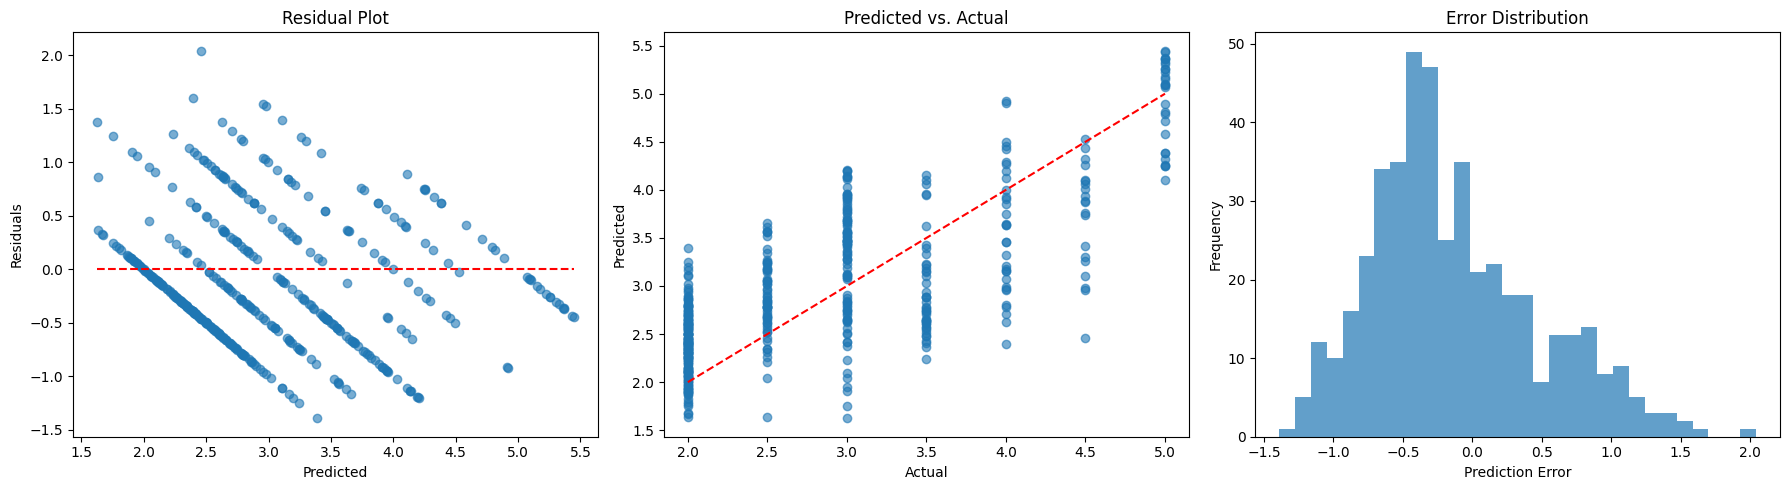

{'mae': 0.5163977098464966, 'mse': 0.38489031716386085, 'rmse': 0.6203952910555179, 'r2': 0.5415115284911125}


In [14]:
emdedding_model_results = evaluate_regression_model(y_test, y_pred, show_plots=True)
print(emdedding_model_results)

################ Get recommendations for specific user

In [15]:
import numpy as np

# --- Select the user with id 1 ---
# (Here we assume that user id 1 corresponds to index 1 in our arrays; adjust if needed.)
user_id = 1
######### only before prediction is the filtering-the training of model is on full datat
temp_df = interaction_data[
    (interaction_data['user_id'] == user_id) &
    (interaction_data['location'] != interaction_data['location_restrictions'])].copy()
user_features_df = temp_df[user_features_names]
item_features_df = temp_df[item_features_names]
start_time = pd.to_datetime("2005-12-01 00:00:00")
time_features_df = extract_time_features(temp_df['timestamp'], start_time)
problem_seq_df = problem_sequences_df[problem_sequences_df['user_id'] == user_id]

problem_sequences_features = []
user_data = {}
for i in range(len(user_features_df)):
    _, weighted_problems = calculate_problem_weights(df_user, "Time_since_first_submission_hours", problem_features, days_window=180, decay_factor=0.01, apply_filter=False)
    problem_sequences_features.append(weighted_problems)

problem_seq_val = np.array(problem_sequences_features)

y_pred_val = best_rs_model.predict([user_features_df, item_features_df, time_features_df, problem_seq_val])
temp_df['pred'] = y_pred_val

In [16]:
problem_seq_val

array([[0, 1, 1, ..., 0, 0, 0],
       [0, 1, 1, ..., 0, 0, 0],
       [0, 1, 1, ..., 0, 0, 0],
       ...,
       [0, 1, 1, ..., 0, 0, 0],
       [0, 1, 1, ..., 0, 0, 0],
       [0, 1, 1, ..., 0, 0, 0]], dtype=int64)

In [20]:
# Add utility score
recommendations = add_utility_scr_recommendations(temp_df, engagement_time=30, alpha=0.3, beta=0.2, gamma=0.5)
print("Final Recommendations (Top Items):")
print(recommendations[['article_id','days_since_last_rating','pred','rating','utility_score']].head(10))

Final Recommendations (Top Items):
    article_id  days_since_last_rating      pred  rating  utility_score
16          17               3002.7500  4.156191     4.5       4.483368
7            8               3587.7500  4.049928     5.0       4.445154
30          31               5007.6250  4.028488     4.5       4.429295
4            5               4097.1665  4.055212     3.0       4.263105
24          25               7126.9585  3.926469     5.0       4.239449
0            1               5717.1665  3.887230     4.5       4.179053
20          21               3629.7500  3.757251     3.0       4.087173
5            6               1771.2916  3.794108     4.5       4.083415
2            3               7124.7500  3.840020     4.5       4.068785
12          13                259.2500  3.994122     4.0       4.029039


In [17]:
temp_df_sorted = temp_df.sort_values('pred', ascending=False)
temp_df_sorted[['article_id','rating','pred','days_since_last_rating']].head(10)

,article_id,rating,pred,days_since_last_rating
8,9,4.5,4.774930,3413.8750
7,8,5.0,4.717092,3587.7500
5,6,4.5,4.642761,1771.2916
34,35,4.5,4.627602,2197.9583
16,17,4.5,4.605495,3002.7500
2,3,4.5,4.595160,7124.7500
40,41,4.5,4.577928,560.0417
25,26,4.5,4.568518,7069.3750
45,46,4.5,4.562939,6663.6250
24,25,5.0,4.555358,7126.9585


In [ ]:
############# DATA needed for ML ops

In [46]:
import numpy as np
import pandas as pd
import os
import json

# Export DataFrames as CSV or JSON (choose based on your needs)
user_features_df.to_csv("../data/user_features_df_postman.txt", index=False)
item_features_df.to_csv("../data/item_features_df_postman.txt", index=False)
time_features_df.to_csv("../data/time_features_df_postman.txt", index=False)
# Save the array
np.save('../data/problem_seq_val_postman.npy', problem_seq_val)

In [21]:
print(best_rs_model.input_names)

['user_feat_input', 'item_feat_input', 'time_input', 'problem_seq_input']


In [26]:
temp_po = final_recommendations.copy()

temp_po.columns

Index(['user_id', 'article_id', 'rating', 'pred', 'Boring presentation',
       'Graphics', 'Readability', 'Consistency', 'Images', 'Bullets',
       'Text size', 'Text heavy', 'Tables', 'Agenda', 'Infographics',
       'Positioning', 'Presentation length', 'General tips',
       'Presentation skills', 'Powerpoint knowledge', 'tips and tricks',
       'Explanation of the problem', 'presentation_type_formal_y',
       'presentation_type_creative_y', 'presentation_type_students_y',
       'presentation_type_technical_y', 'presentation_type_branding_y',
       'audience_type_academic', 'audience_type_business',
       'audience_type_kids', 'audience_type_general', 'audience_type_creative',
       'audience_type_specialized', 'days_since_last_rating',
       'submission_date', 'popularity', 'audience_boost', 'age_days',
       'freshness_score', 'inverse_popularity', 'long_tail_boost',
       'utility_score'],
      dtype='object')

In [27]:
############################### Step 6 evaluate the RS

In [41]:
import pandas as pd

def calculate_precision(df, true_rating_col, predicted_rating_col, relevance_threshold):
    """
    Calculate precision as:
    Precision = Relevant Recommended Items / Total Recommended Items.

    Parameters:
        df (pd.DataFrame): The dataset containing true and predicted ratings.
        true_rating_col (str): Column name for true ratings.
        predicted_rating_col (str): Column name for predicted ratings.
        relevance_threshold (float): threshold to determine relevance.

    Returns:
        float: Precision value.
    """
    print("Relevance threshold: " + str(relevance_threshold))

    # Determine relevant items based on true ratings
    df['is_relevant'] = df[true_rating_col] >= relevance_threshold

    # Determine predicted relevant items based on predicted ratings
    df['predicted_relevant'] = df[predicted_rating_col] >= relevance_threshold

    # Calculate Relevant Recommended Items (both relevant & predicted as relevant)
    relevant_recommended = df[(df['is_relevant']) & (df['predicted_relevant'])].shape[0]

    # Calculate Total Recommended Items (all predicted as relevant)
    total_recommended = df['predicted_relevant'].sum()

    # Calculate Precision
    precision = (relevant_recommended / total_recommended if total_recommended > 0 else 0)

    return precision

# Calculate precision
relevance_threshold = ratings_matrix['rating'].quantile(0.90)
precision = calculate_precision(temp_po, 'rating', 'pred', relevance_threshold)
print(f"Precision: {precision:.4f}")


Relevance threshold: 4.5
Precision: 1.0000


In [29]:
import numpy as np
import pandas as pd

def compute_novelty(data: pd.DataFrame, final_recommendations: pd.DataFrame) -> tuple:
    """
    Computes the novelty and serendipity of the recommended articles using the pre-calculated popularity column.

    Parameters:
        data (pd.DataFrame): DataFrame containing all articles, including the popularity column.
        final_recommendations (pd.DataFrame): DataFrame containing recommended articles.

    Returns:
        tuple: (Average Novelty Score, Average Serendipity Score)
    """
    # Step 1: Aggregate and normalize popularity to ensure it stays between 0 and 1
    min_popularity = data['popularity'].min()
    max_popularity = data['popularity'].max()

    if max_popularity == min_popularity:
        data['normalized_popularity'] = 0.5  # If all popularity values are the same, assign a neutral value
    else:
        data['normalized_popularity'] = (data['popularity'] - min_popularity) / (max_popularity - min_popularity)
    
    # Step 2: Map normalized popularity values
    article_popularity = data.groupby('article_id')['normalized_popularity'].mean().to_dict()  # Ensure unique IDs
    
    # Step 3: Compute novelty scores (inverse of normalized popularity)
    novelty_scores = {k: 1 - v for k, v in article_popularity.items()}  # Less popular = Higher novelty

    # Step 4: Map novelty scores to recommended articles
    final_recommendations['novelty_score'] = final_recommendations['article_id'].map(novelty_scores).fillna(1)  # Unseen articles get max novelty

    # Step 5: Compute relevance score (Normalize ratings)
    if 'rating' in final_recommendations.columns:
        max_rating = final_recommendations['rating'].max()
        final_recommendations['relevance_score'] = final_recommendations['rating'] / max_rating if max_rating > 0 else 0
    else:
        final_recommendations['relevance_score'] = 1  # If no ratings, assume max relevance
    
    # Step 6: Compute serendipity as novelty * relevance
    avg_serendipity = (final_recommendations['novelty_score'] * final_recommendations['relevance_score']).mean()
    
    # Step 7: Compute average novelty
    avg_novelty = final_recommendations['novelty_score'].mean()
    
    return avg_novelty, avg_serendipity

# ------------------------------------------------------------------------------
# Example Usage:
# ------------------------------------------------------------------------------
novelty_score, serendipity_score = compute_novelty(interaction_data.copy(), final_recommendations.copy())

print(f"✅ Fixed Average Novelty Score: {novelty_score:.4f}")
print(f"✅ Fixed Average Serendipity Score: {serendipity_score:.4f}")


✅ Fixed Average Novelty Score: 0.4553
✅ Fixed Average Serendipity Score: 0.4262


In [30]:
Diversity measures how different the recommended items are from each other. It’s typically calculated using pairwise similarity between items in the recommendations.

Steps:

Calculate pairwise similarity for the features column. Compute the average dissimilarity (1 - similarity) for all pairs of recommendations.

SyntaxError: invalid syntax (1049687216.py, line 1)

In [31]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

def calculate_diversity(recommended_items, item_features, item_id_col="article_id"):
    """
    Calculates diversity of recommendations based on item feature similarity.

    Args:
        recommended_items (DataFrame): DataFrame containing recommended items.
        item_features (list): List of column names representing item features.
        item_id_col (str): Column name in `final_rec` and `tada1` representing item IDs.

    Returns:
        float: Diversity score (higher means more diverse recommendations).
    """

    # Ensure we have enough items to calculate diversity
    if recommended_items.shape[0] < 2:
        return 1.0  # Maximum diversity if only one or zero items are recommended

    # Compute pairwise cosine similarity
    similarity_matrix = cosine_similarity(recommended_items[['Boring presentation',
         'Graphics',
         'Readability',
         'Consistency',
         'Images',
         'Bullets',
         'Text size',
         'Text heavy',
         'Tables',
         'Agenda',
         'Infographics',
         'Positioning',
         'Presentation length',
         'General tips',
         'Presentation skills',
         'Powerpoint knowledge',
         'tips and tricks',
         'Explanation of the problem']])

    # Get upper triangle values (excluding diagonal)
    sim_values = similarity_matrix[np.triu_indices(len(recommended_items), k=1)]

    # Calculate diversity (1 - mean similarity)
    diversity_score = 1 - np.mean(sim_values) if len(sim_values) > 0 else 1.0
    
    return round(diversity_score,2)


calculate_diversity(final_recommendations, item_features)

0.49

In [32]:
Types of Coverage:
User Coverage:

The percentage of users for whom the system can provide recommendations.
If coverage = 1, it means the system has made recommendations for 100% of the users.
Formula:

User Coverage
=
Users with Recommendations
Total Users
User Coverage=
Total Users
Users with Recommendations
​

Item Coverage:

The percentage of items that appear in at least one recommendation list.
If coverage = 1, it means every item in the catalog has been recommended at least once.
Formula:

Item Coverage
=
Items in Recommendations
Total Items
Item Coverage=
Total Items
Items in Recommendations
​

Example Interpretation:
User Coverage = 1:
The system is able to generate recommendations for all users in the dataset.
Item Coverage = 1:
The system has recommended all items from the catalog to at least one user.
Why Is Coverage Important?
Coverage is critical in recommendation systems for the following reasons:

Inclusivity: Ensures that all users or items are considered, preventing bias.
Diversity: Higher item coverage generally correlates with more diverse recommendations.

SyntaxError: invalid syntax (3360879187.py, line 1)

In [33]:
final_recommendations

,user_id,article_id,rating,pred,Boring presentation,Graphics,Readability,Consistency,Images,Bullets,...,audience_type_specialized,days_since_last_rating,submission_date,popularity,audience_boost,age_days,freshness_score,inverse_popularity,long_tail_boost,utility_score
8,1,9,4.5,4.774930,0,0,1,1,1,0,...,0,3413.8750,2025-02-14 00:00:00+00:00,1.93,0,123,0.982501,0.009473,0.495987,5.485420
7,1,8,5.0,4.717092,0,0,0,0,0,0,...,0,3587.7500,2024-04-15 02:00:00+00:00,0.69,0,428,0.939109,0.037033,0.488071,5.407775
5,1,6,4.5,4.642761,1,1,1,0,1,1,...,0,1771.2916,2020-11-04 15:00:00+00:00,3.48,0,1685,0.760279,0.002563,0.381421,5.174015
16,1,17,4.5,4.605495,1,0,0,1,0,1,...,0,3002.7500,2021-05-13 10:00:00+00:00,4.77,0,1496,0.787167,0.000229,0.393698,5.149448
24,1,25,5.0,4.555358,0,1,0,0,0,0,...,0,7126.9585,2021-07-15 04:00:00+00:00,4.15,0,1433,0.796130,0.001170,0.398650,5.100156
34,1,35,4.5,4.627602,0,1,0,0,0,1,...,0,2197.9583,2018-11-17 08:00:00+00:00,2.60,0,2404,0.657988,0.005479,0.331734,5.088142
30,1,31,4.5,4.423069,0,1,0,0,0,0,...,0,5007.6250,2025-05-05 13:00:00+00:00,4.06,0,43,0.993882,0.001331,0.497607,5.083353
2,1,3,4.5,4.595160,1,0,1,0,0,0,...,0,7124.7500,2017-01-30 13:00:00+00:00,0.80,0,3060,0.564661,0.031177,0.297919,5.005856
25,1,26,4.5,4.568518,0,1,1,0,1,1,...,0,7069.3750,2016-03-26 15:00:00+00:00,3.57,0,3369,0.520700,0.002346,0.261523,4.926949
62,1,63,4.5,4.277230,0,1,1,0,1,0,...,0,3257.3750,2024-01-11 19:00:00+00:00,0.96,0,522,0.925736,0.025031,0.475384,4.887227


In [34]:
# Ensure total_items is properly assigned
total_items = interaction_data['article_id'].nunique()  # Count unique articles in the full dataset
print(total_items)  # Should print the correct number of unique articles
#500
# Count unique articles in recommendations
items_in_recommendations = final_recommendations['article_id'].nunique()
print(items_in_recommendations)  # Should print the correct number of unique articles in recommendations

# Compute item coverage
item_coverage = items_in_recommendations / total_items

# Print correct item coverage
print(f"Item Coverage: {item_coverage:.4f}")  # Corrected print statement


100
15
Item Coverage: 0.1500


In [25]:
####retrying